In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Colors

In [2]:
colors_df = pd.read_csv('../data/lego/colors.csv')

In [3]:
colors_df.head(3)

,id,name,rgb,is_trans
0,-1,Unknown,0033B2,f
1,0,Black,05131D,f
2,1,Blue,0055BF,f


In [20]:
print(f"Number of Unique Colors: {colors_df.nunique()['name']}")
print(f"Number of Transparent: {colors_df.is_trans.value_counts()['t']}")
print(f"Number of Non-Transparent: {colors_df.is_trans.value_counts()['f']}")

Number of Unique Colors: 135
Number of Transparent: 28
Number of Non-Transparent: 107


---

## Sets

In [21]:
sets_df = pd.read_csv('../data/lego/sets.csv')

In [22]:
sets_df.head(3)

,set_num,name,year,theme_id,num_parts
0,001-1,Gears,1965,1,43
1,0011-2,Town Mini-Figures,1978,84,12
2,0011-3,Castle 2 for 1 Bonus Offer,1987,199,0


In [37]:
first_year = sets_df.year.min()
first_sets = sets_df[sets_df['year'] == first_year]['name']

print(f"""First Lego Sets were realeased in {first_year} and those were:
{list(first_sets)}""")

First Lego Sets were realeased in 1949 and those were:
['Extra-Large Gift Set (ABB)', 'Large Gift Set (ABB)', 'Medium Gift Set (ABB)', 'Small Brick Set (ABB)', 'Small Doors and Windows Set (ABB)']


### Aggregate

**The Number of Sets Released By Year**

In [65]:
sets_by_year = sets_df.groupby('year').count()

**The Number of Themes Released By Year**

In [66]:
themes_by_year = sets_df.groupby('year').agg({'theme_id' : pd.Series.nunique})

**The Number of Sets Released By Year**

---

### Themes

In [70]:
themes_df = pd.read_csv('../data/lego/themes.csv')

In [71]:
themes_df.head()

,id,name,parent_id
0,1,Technic,NaN
1,2,Arctic Technic,1.0
2,3,Competition,1.0
3,4,Expert Builder,1.0
4,5,Model,1.0


---

### Merge

In [105]:
df1_agg = sets_df.groupby('theme_id').count()
df1 = pd.DataFrame({'id' : df1_agg.index,
                   'set_count': df1_agg['name'] })

merge_df = pd.merge(df1, themes_df, on='id')
merge_df.sort_values('set_count', inplace=True, ascending=False)
merge_df.head(3)

,id,set_count,name,parent_id
134,158,753,Star Wars,NaN
384,501,656,Gear,NaN
379,494,398,Friends,NaN


---

### Charts

**The Number of Sets Released By Year**

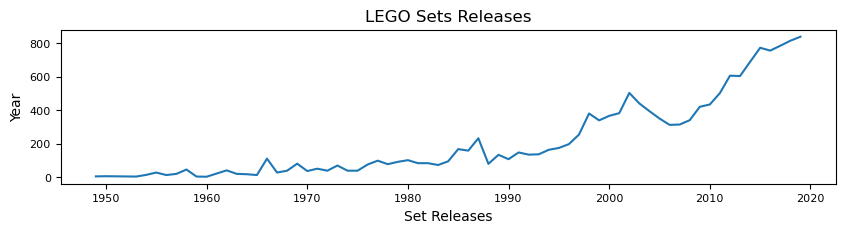

In [68]:
fig, ax = plt.subplots(figsize=(10,2))

x = sets_by_year.index[:-2]
y = sets_by_year.set_num[:-2]

ax.plot(x,y)
ax.set_title('LEGO Sets Releases')
ax.set_xlabel('Set Releases')
ax.set_ylabel('Year')
ax.tick_params(axis='both', labelsize=8)

**The Number of Themes Released By Year**

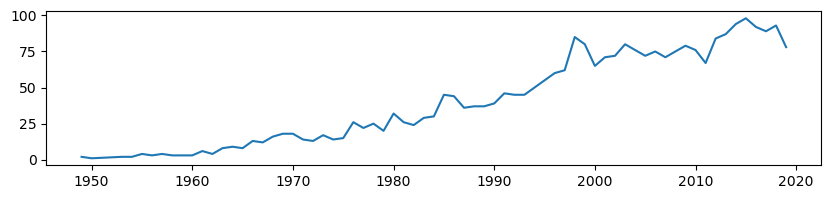

In [69]:
plt.figure(figsize=(10,2))
plt.plot(themes_by_year.index[:-2], themes_by_year.values[:-2])

**The Number of Sets By Theme Name**

<BarContainer object of 10 artists>

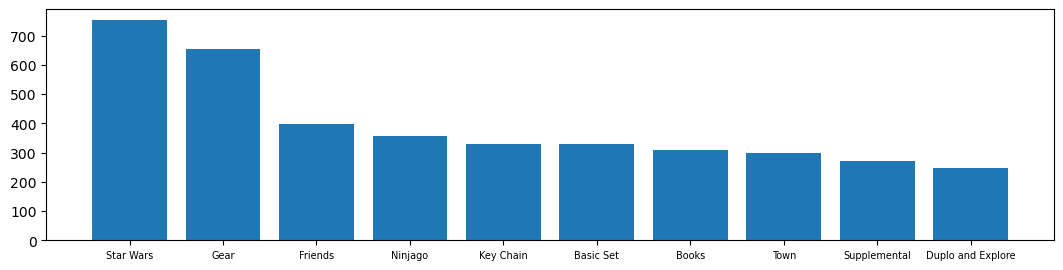

In [112]:
plt.figure(figsize=(13,3))
plt.xticks(fontsize=7)
plt.bar(merge_df.name[:10], merge_df.set_count[:10])